# Frequency Sweep: 5000–9000 MHz

Sweeps a CW pulse from 5000 to 9000 MHz and plots magnitude vs frequency for two setups:
- **Setup 1**: DAC → balun → VLF-7200+ LPF → balun → ADC (Gen 0 / RO 0)
- **Setup 2**: DAC → balun → balun → ADC, no filter (Gen 2 / RO 1)

The LPF cutoff at 7200 MHz should be visible as a rolloff in Setup 1.

In [3]:
from qick import *
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline

In [4]:
# Initialize QICK
soc = QickSoc()
soccfg = soc
print(soccfg)

QICK running on ZCU216, software version 0.2.396

Firmware configuration (built Mon Aug 21 11:09:34 2023):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc clock, DAC tile 2], [DAC tile 3], [ADC tile 2]

	7 signal generator channels:
	0:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 65536 complex samples (9.524 us)
		32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 65536 complex samples (9.524 us)
		32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 65536 complex samples (9.524 us)
		32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 2 is 2_230 on JHC3, or QICK box DAC port 10
	3:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory

In [5]:
# ── Channel assignments ────────────────────────────────────────────────────────
# Setup 1: with 7200 MHz LPF in the signal path
GEN_CH_1 = 0   # DAC port 8  (DAC tile 2, blk 0, JHC3)
RO_CH_1  = 0   # ADC port 4  (ADC tile 2, blk 0, JHC7)

# Setup 2: no filter, baluns only
GEN_CH_2 = 2   # DAC port 10 (DAC tile 2, blk 2, JHC3)
RO_CH_2  = 1   # ADC port 6  (ADC tile 2, blk 2, JHC7)

print(f"Setup 1 — Gen ch {GEN_CH_1} → RO ch {RO_CH_1} (with LPF)")
print(f"Setup 2 — Gen ch {GEN_CH_2} → RO ch {RO_CH_2} (no filter)")

Setup 1 — Gen ch 0 → RO ch 0 (with LPF)
Setup 2 — Gen ch 2 → RO ch 1 (no filter)


In [6]:
# ── LoopbackProgram ────────────────────────────────────────────────────────────
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg = self.cfg
        res_ch = cfg["res_ch"]

        # NQZ=2 for frequencies above FS/2 = 3440.64 MHz
        self.declare_gen(ch=res_ch, nqz=cfg["nqz"])

        # Configure readout DDC — freq and gen_ch ensure DAC/ADC frequency matching
        for ch in cfg["ro_chs"]:
            self.declare_readout(
                ch=ch,
                length=cfg["readout_length"],
                freq=cfg["pulse_freq"],
                gen_ch=res_ch
            )

        freq  = self.freq2reg(cfg["pulse_freq"], gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        self.default_pulse_registers(
            ch=res_ch, freq=freq, phase=phase, gain=cfg["pulse_gain"]
        )
        self.set_pulse_registers(ch=res_ch, style="const", length=cfg["length"])
        self.synci(200)

    def body(self):
        self.measure(
            pulse_ch=self.cfg["res_ch"],
            adcs=self.ro_chs,
            pins=[0],
            adc_trig_offset=self.cfg["adc_trig_offset"],
            wait=True,
            syncdelay=self.us2cycles(self.cfg["relax_delay"])
        )

In [13]:
# ── Sweep parameters ───────────────────────────────────────────────────────────
# Frequency points to sweep (MHz)
freqs_mhz = np.linspace(4000, 9000, 100)  # 50 MHz steps — increase points for finer resolution

# Shared config for both setups
# NOTE:
#   - nqz=2 required for 5000-9000 MHz (above DAC FS/2 = 3440.64 MHz)
#   - reps controls SNR — increase if traces look noisy
#   - length and readout_length in DAC/ADC clock ticks respectively
#   - adc_trig_offset: delay (tProc ticks) between pulse fire and ADC window open
base_config = {
    "reps":           200,
    "relax_delay":    1.0,    # µs between shots
    "res_phase":      0,      # degrees
    "pulse_style":    "const",
    "length":         100,    # DAC clock ticks
    "readout_length": 200,    # ADC clock ticks
    "pulse_gain":     30000,  # DAC units (max 32767)
    "adc_trig_offset":100,    # tProc clock ticks
    "soft_avgs":      1,      # 1 here — averaging handled by reps
    "nqz":            2,
}

print(f"Sweeping {len(freqs_mhz)} frequency points from {freqs_mhz[0]:.0f} to {freqs_mhz[-1]:.0f} MHz")
hardware_time_s = len(freqs_mhz) * 2 * base_config['reps'] * base_config['relax_delay'] * 1e-6
print(f"Hardware-only minimum: ~{hardware_time_s:.2f} s")
print(f"Realistic estimate with Python overhead: ~{len(freqs_mhz) * 2 * 0.5:.0f}–{len(freqs_mhz) * 2 * 2:.0f} s")
print(f"  ({len(freqs_mhz) * 2} program compile+acquire calls, roughly 0.5–2 s each)")

Sweeping 100 frequency points from 4000 to 9000 MHz
Hardware-only minimum: ~0.04 s
Realistic estimate with Python overhead: ~100–400 s
  (200 program compile+acquire calls, roughly 0.5–2 s each)


In [8]:
# ── Run frequency sweep ────────────────────────────────────────────────────────
mags1       = []   # Setup 1: with LPF
mags2       = []   # Setup 2: no filter
actual_freqs = []  # Actual frequencies after adcfreq() rounding

for freq in tqdm(freqs_mhz, desc="Frequency sweep"):

    # Round to nearest frequency exactly representable by both DAC and ADC
    f1 = soccfg.adcfreq(freq, GEN_CH_1, RO_CH_1)
    f2 = soccfg.adcfreq(freq, GEN_CH_2, RO_CH_2)
    actual_freqs.append(f1)

    # ── Setup 1: with LPF ────────────────────────────────────────────────────
    config1 = {
        **base_config,
        "res_ch":    GEN_CH_1,
        "ro_chs":    [RO_CH_1],
        "pulse_freq": f1,
    }
    prog1 = LoopbackProgram(soccfg, config1)
    avgi1, avgq1 = prog1.acquire(soc, load_pulses=True, progress=False)
    mags1.append(np.sqrt(avgi1[0][0]**2 + avgq1[0][0]**2))

    # ── Setup 2: no filter ───────────────────────────────────────────────────
    config2 = {
        **base_config,
        "res_ch":    GEN_CH_2,
        "ro_chs":    [RO_CH_2],
        "pulse_freq": f2,
    }
    prog2 = LoopbackProgram(soccfg, config2)
    avgi2, avgq2 = prog2.acquire(soc, load_pulses=True, progress=False)
    mags2.append(np.sqrt(avgi2[0][0]**2 + avgq2[0][0]**2))

mags1        = np.array(mags1)
mags2        = np.array(mags2)
actual_freqs = np.array(actual_freqs)

print("Sweep complete.")

Frequency sweep: 100%|██████████| 100/100 [00:01<00:00, 68.72it/s]

Sweep complete.


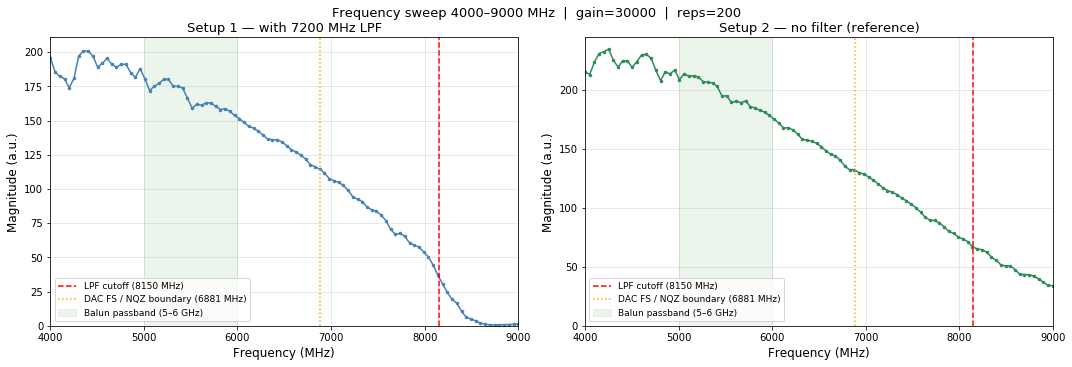

Plot saved to frequency_sweep_result.png


In [12]:
# ── Plot results ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_data = [
    (axes[0], mags1, "Setup 1 — with 7200 MHz LPF",   "steelblue"),
    (axes[1], mags2, "Setup 2 — no filter (reference)", "seagreen"),
]

for ax, mags, title, color in plot_data:
    ax.plot(actual_freqs, mags, color=color, linewidth=1.5, marker='.', markersize=5)

    # Reference lines
    ax.axvline(x=8150,    color='red',    linestyle='--', linewidth=1.5, label='LPF cutoff (8150 MHz)')
    ax.axvline(x=6881.28, color='orange', linestyle=':',  linewidth=1.5, label='DAC FS / NQZ boundary (6881 MHz)')
    ax.axvspan(5000, 6000, alpha=0.08, color='green', label='Balun passband (5–6 GHz)')

    ax.set_xlabel("Frequency (MHz)", fontsize=12)
    ax.set_ylabel("Magnitude (a.u.)", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_xlim(freqs_mhz[0], freqs_mhz[-1])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35)

plt.suptitle(
    f"Frequency sweep {freqs_mhz[0]:.0f}–{freqs_mhz[-1]:.0f} MHz  |  "
    f"gain={base_config['pulse_gain']}  |  reps={base_config['reps']}",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("frequency_sweep_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to frequency_sweep_result.png")

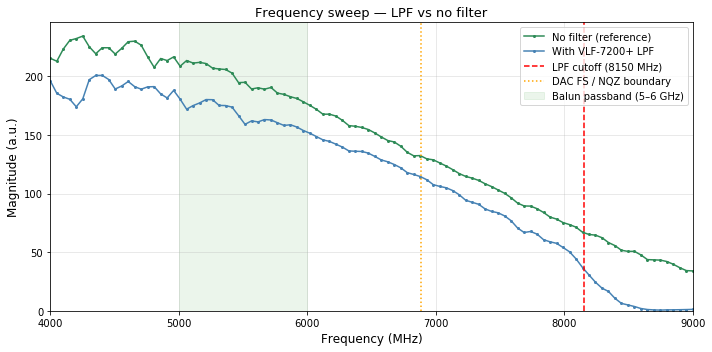

Overlay plot saved to frequency_sweep_overlay.png


In [10]:
# Overlay both setups on a single axis for direct comparison ──────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(actual_freqs, mags2, color='seagreen',  linewidth=1.5, marker='.', markersize=4, label='No filter (reference)')
ax.plot(actual_freqs, mags1, color='steelblue', linewidth=1.5, marker='.', markersize=4, label='With VLF-7200+ LPF')

ax.axvline(x=8150,    color='red',    linestyle='--', linewidth=1.5, label='LPF cutoff (8150 MHz)')
ax.axvline(x=6881.28, color='orange', linestyle=':',  linewidth=1.5, label='DAC FS / NQZ boundary')
ax.axvspan(5000, 6000, alpha=0.08, color='green', label='Balun passband (5–6 GHz)')

ax.set_xlabel("Frequency (MHz)", fontsize=12)
ax.set_ylabel("Magnitude (a.u.)", fontsize=12)
ax.set_title("Frequency sweep — LPF vs no filter", fontsize=13)
ax.set_xlim(freqs_mhz[0], freqs_mhz[-1])
ax.set_ylim(bottom=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig("frequency_sweep_overlay.png", dpi=150, bbox_inches='tight')
plt.show()
print("Overlay plot saved to frequency_sweep_overlay.png")

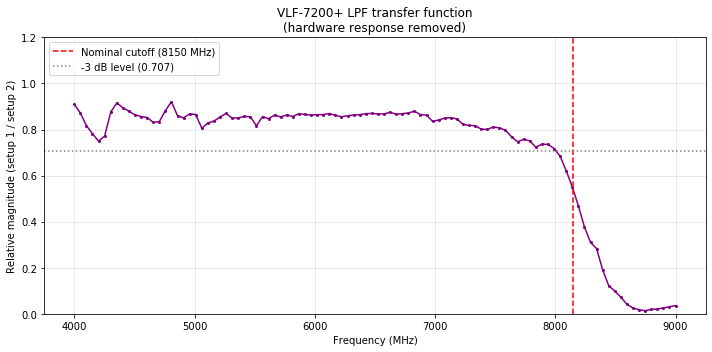

In [11]:
# Avoid division by zero
safe_mags2 = np.where(mags2 > 0.1, mags2, np.nan)
filter_response = mags1 / safe_mags2

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(actual_freqs, filter_response, color='purple', linewidth=1.5, marker='.', markersize=4)
ax.axvline(x=8150, color='red', linestyle='--', linewidth=1.5, label='Nominal cutoff (8150 MHz)')
ax.axhline(y=1/np.sqrt(2), color='gray', linestyle=':', label='-3 dB level (0.707)')
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Relative magnitude (setup 1 / setup 2)")
ax.set_title("VLF-7200+ LPF transfer function\n(hardware response removed)")
ax.set_ylim(0, 1.2)
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()